1. Project Overview
Konteks masalah: Perusahaan telekomunikasi kehilangan pelanggan (churn),dan tim retensi hanya memiliki kapasitas terbatas untuk menghubungi pelanggan.

**Tujuan prediksi**: Memperkirakan probabilitas seorang pelanggan akan berhentiberlangganan (churn), sehingga tim retensi dapat memprioritaskan kontak kepelanggan berisiko tinggi.

**Tipe tugas**: Binary classification
Target: Churn (Yes/No)
Unit of analysis: Satu pelanggan aktif (satu baris = satu pelanggan)
Pengguna & nilai bisnis: Tim retensi — prediksi mengarah pada keputusan"siapa yang harus dihubungi", bukan sekadar skor akurasi.

**Dataset: Telco Customer Churn (fokus pada program retensi pelanggan).**
Pemilik data: IBM (sample data), dihosting di Kaggle oleh blastchar.
Link: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
Diakses tanggal: Minggu, 27 September 2026



In [2]:
# =====================================================
# 0. IMPORT LIBRARY & KONFIGURASI GLOBAL
# =====================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42          # dipakai konsisten di semua step acak (split, model, dst.)
pd.set_option("display.max_columns", None)

print("Setup selesai ✅")

Setup selesai ✅


1. Project Overview
2. Dataset Description and Source
3. Data Quality Assessment
4. Data Preparation
5. Exploratory Data Analysis
6. Feature Engineering
7. Baseline Model
8. Model Training
9. Model Evaluation
10. Feature Importance
11. Conclusion and Recommendations

# **Section 1 — Project Overview:**

**1. Project Overview**

Konteks masalah: Perusahaan telekomunikasi kehilangan pelanggan (churn),dan tim retensi hanya memiliki kapasitas terbatas untuk menghubungi pelanggan.

Tujuan prediksi: Memperkirakan probabilitas seorang pelanggan akan berhentiberlangganan (churn), sehingga tim retensi dapat memprioritaskan kontak kepelanggan berisiko tinggi.

Tipe tugas: Binary classification
Target: Churn (Yes/No)
Unit of analysis: Satu pelanggan aktif (satu baris = satu pelanggan)
Pengguna & nilai bisnis: Tim retensi — prediksi mengarah pada keputusan"siapa yang harus dihubungi", bukan sekadar skor akurasi.

In [3]:
# =====================================================
# 2. LOAD DATASET
# =====================================================
df_raw = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Dimensi dataset:", df_raw.shape)
df_raw.head()

Dimensi dataset: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# --- Audit 1: struktur & tipe data ---
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# **Section 2 — Dataset Description:**

2. Dataset Description and Source
Sitasi dataset:

Judul: Telco Customer Churn
Pemilik data: IBM (sample data set), dihosting di Kaggle oleh blastchar
Link: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
Tanggal akses: 27 September 2026
Dimensi: 7.043 baris × 21 kolom. Satu baris = satu pelanggan.

Target: Churn (Yes/No).

Prediktor (20 kolom):

Demografi: gender, SeniorCitizen, Partner, Dependents
Akun: tenure, Contract, PaperlessBilling, PaymentMethod
Layanan: PhoneService, MultipleLines, InternetService,OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport,StreamingTV, StreamingMovies
Tagihan: MonthlyCharges, `TotalCharges

In [5]:
# --- Audit 2: missing values & duplikat ---
print(df_raw.isnull().sum())
print("Jumlah duplikat:", df_raw.duplicated().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
Jumlah duplikat: 0


# **Section 3 — Data Quality Assessment:**

**3. Data Quality Assessment - Hasil audit (bukti kode di bawah):**

Struktur: 7.043 × 21, tanpa duplikat baris.
Missing values semu: isnull() = 0 di semua kolom, NAMUN TotalCharges tersimpan sebagai object. Konversi to_numericmenyingkap 11 blank tersembunyi.

Sifat missing: semua 11 baris memiliki tenure = 0 → pelanggan baruyang belum pernah ditagih. Ini missing struktural, bukan acak.

Label struktural: No phone service (682) persis sama dengan jumlahPhoneService = No (682); No internet service (1.526) persis sama dengan

InternetService = No (1.526) → layanan struktural tidak tersedia,maknanya berbeda dari No.Tipe menyesatkan: SeniorCitizen tersimpan 0/1 tetapi merupakankategori, bukan besaran.
  
Distribusi target: No 73,5% vs Yes 26,5% → imbalance. Akurasidapat menipu (prediksi "No" semua sudah 73,5%), sehingga evaluasi akanmenggunakan metrik class-sensitive: precision, recall, F1.

In [6]:
# --- Audit 3: distribusi target ---
df_raw["Churn"].value_counts(normalize=True)

,proportion
Churn,
No,0.73463
Yes,0.26537


# **Section 4 — Data Preparation:**

**4. Data Preparation - Keputusan dan justifikasi:**

TotalCharges → konversi ke numeric; 11 blank (tenure=0) diimpute 0karena secara domain pelanggan yang belum ditagih memang totaltagihannya 0. Median populasi (±1.400) justru salah secara bisnis.
customerID → di-drop (7.043 nilai unik / 7.043 baris, identifiertanpa sinyal prediktif).
Label No phone service / No internet service → dipertahankansebagai kategori terpisah (makna struktural berbeda dari No);akan ditangani One-Hot Encoding di Section 6.
SeniorCitizen → dikonversi 0/1 menjadi Yes/No (kategori eksplisit).
Target Churn → Yes/No dipetakan ke 1/0.

In [7]:
# --- Audit 4: investigasi TotalCharges ---
print("Tipe data TotalCharges:", df_raw["TotalCharges"].dtype)

# cari baris yang TIDAK bisa dikonversi ke angka
mask = pd.to_numeric(df_raw["TotalCharges"], errors="coerce").isnull()
print("Baris dengan TotalCharges bermasalah:", mask.sum())
df_raw[mask][["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

Tipe data TotalCharges: object
Baris dengan TotalCharges bermasalah: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [8]:
# =====================================================
# 4. DATA PREPARATION
# =====================================================
df = df_raw.copy()  # jaga raw tetap utuh

# 4a. Konversi TotalCharges: object -> numeric
#     blank " " dari tenure=0 diimpute 0 (aturan domain, lihat markdown di atas)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("NaN setelah konversi:", df["TotalCharges"].isnull().sum())

mask_new = df["tenure"] == 0
df.loc[mask_new, "TotalCharges"] = 0
print("Imputasi 0 pada baris tenure=0:", mask_new.sum())
print("Tipe data TotalCharges sekarang:", df["TotalCharges"].dtype)

NaN setelah konversi: 11
Imputasi 0 pada baris tenure=0: 11
Tipe data TotalCharges sekarang: float64


In [9]:
# 4b. Audit label kategorikal — cari label yang "nyasar"
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


customerID:
customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
8775-CEBBJ    1
2823-LKABH    1
             ..
6713-OKOMC    1
1452-KIOVK    1
9305-CDSKC    1
9237-HQITU    1
7795-CFOCW    1
Name: count, Length: 7043, dtype: int64

gender:
gender
Male      3555
Female    3488
Name: count, dtype: int64

Partner:
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents:
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

PhoneService:
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

MultipleLines:
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

InternetService:
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

OnlineSecurity:
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

OnlineBackup:
OnlineBackup
No                     3088
Yes                

In [10]:
# 4c. Penanganan identifier, label struktural, dan target

# (a) customerID: identifier unik (7043 nilai unik / 7043 baris), tanpa sinyal prediktif
df = df.drop(columns=["customerID"])

# (b) Label "No phone service"/"No internet service" DIPERTAHANKAN sebagai kategori
#     (keputusan + alasan sudah dijelaskan di markdown di atas)

# (c) SeniorCitizen: 0/1 adalah kode kategori, bukan besaran
df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})

# (d) Target: Yes/No -> 1/0 (deterministik, aman sebelum split)
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

print(df.dtypes)
print(df["Churn"].value_counts())

gender               object
SeniorCitizen        object
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object
Churn
0    5174
1    1869
Name: count, dtype: int64


# **5. Exploratory Data Analysis**

EDA difokuskan untuk menjawab: faktor apa yang membedakan pelanggan yangchurn? Hasilnya akan menentukan feature engineering dan memberi konteksinterpretasi model. Fokus: 3 fitur numerik + kategori kunci terkaitkontrak, layanan internet, dan metode pembayaran.

In [11]:
# 5a. Statistik deskriptif fitur numerik
df[["tenure", "MonthlyCharges", "TotalCharges"]].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


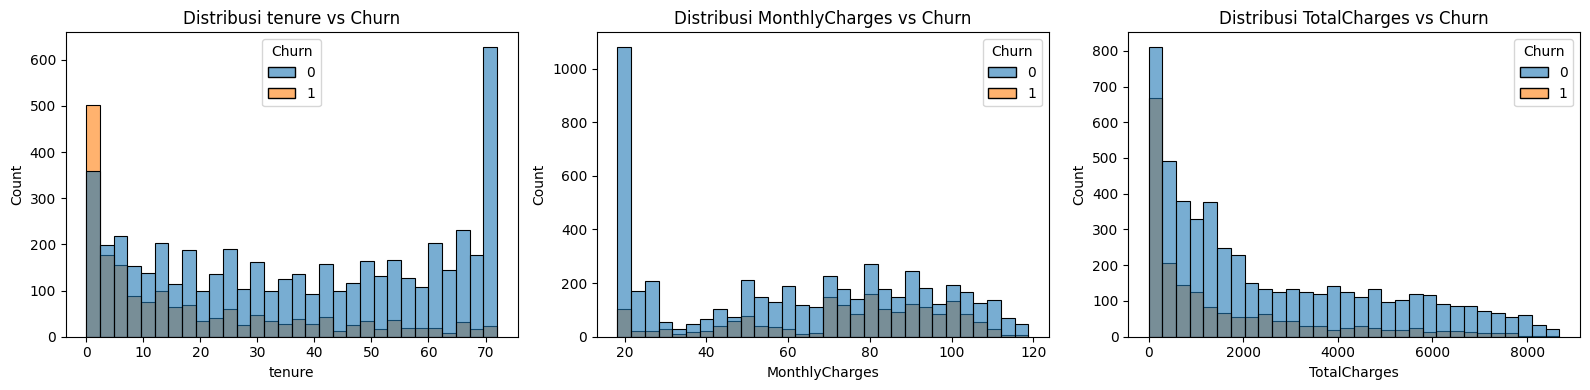

In [12]:
# 5b. Distribusi numerik per kelas churn (0 = tidak churn, 1 = churn)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    sns.histplot(data=df, x=col, hue="Churn", bins=30, alpha=0.6, ax=ax)
    ax.set_title(f"Distribusi {col} vs Churn")
plt.tight_layout()
plt.show()

5c — Churn rate per kategori (ini yang paling penting buat cerita bisnis):



In [13]:
# 5c. Rata-rata churn (= churn rate) per kategori
cat_check = ["Contract", "InternetService", "PaymentMethod",
             "TechSupport", "OnlineSecurity", "SeniorCitizen"]
for col in cat_check:
    print(f"\n--- {col} ---")
    print(df.groupby(col)["Churn"].mean().sort_values(ascending=False).round(3))


--- Contract ---
Contract
Month-to-month    0.427
One year          0.113
Two year          0.028
Name: Churn, dtype: float64

--- InternetService ---
InternetService
Fiber optic    0.419
DSL            0.190
No             0.074
Name: Churn, dtype: float64

--- PaymentMethod ---
PaymentMethod
Electronic check             0.453
Mailed check                 0.191
Bank transfer (automatic)    0.167
Credit card (automatic)      0.152
Name: Churn, dtype: float64

--- TechSupport ---
TechSupport
No                     0.416
Yes                    0.152
No internet service    0.074
Name: Churn, dtype: float64

--- OnlineSecurity ---
OnlineSecurity
No                     0.418
Yes                    0.146
No internet service    0.074
Name: Churn, dtype: float64

--- SeniorCitizen ---
SeniorCitizen
Yes    0.417
No     0.236
Name: Churn, dtype: float64


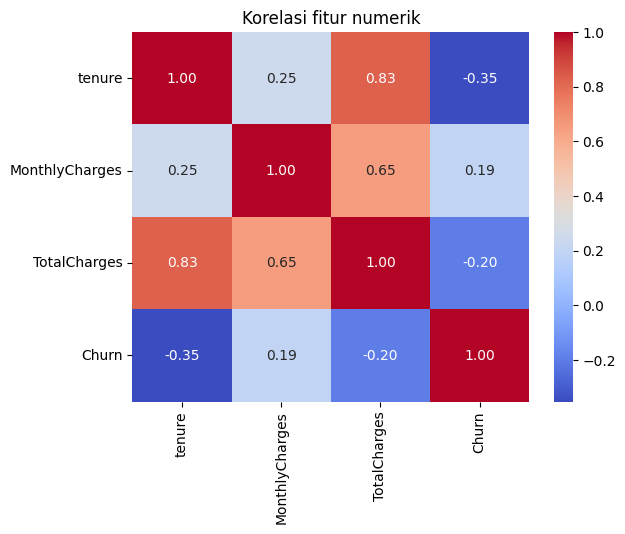

In [14]:
# 5d. Heatmap korelasi fitur numerik + target
corr = df[["tenure", "MonthlyCharges", "TotalCharges", "Churn"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Korelasi fitur numerik")
plt.show()

Interpretasi EDA

Kontrak month-to-month memiliki churn rate 42,7%, jauh di atas two-year contract (2,8%)(one-year 11,3%) → semakin panjang komitmen kontrak, semakin rendah churn; faktor dominan.

Pelanggan fiber optic churn 41,9% vs DSL 19,0% (tanpa internet hanya 7,4%) → fiber terkaitrisiko tinggi. Hubungan ini prediktif, bukan kausal (kemungkinan terkait harga paket dan tipekontrak yang ikut berbeda di segmen fiber).

Pembayaran electronic check churn 45,3% vs automatic payment (credit card / bank transfer)15–17% → pembayaran otomatis berkorelasi kuat dengan retensi.

Churn terkonsentrasi pada tenure rendah → pelanggan baru adalah kelompok risiko utama.

Temuan tambahan: senior citizen churn 41,7% vs 23,6%; pelanggan tanpa TechSupport/OnlineSecuritychurn ±41–42% vs ±15% yang mengambil (≈2,7×).

Korelasi tenure–TotalCharges = 0,83 → multicollinearity; koefisien logistic regression perludiinterpretasi hati-hati. Korelasi dengan target: tenure −0,35 (protektif), MonthlyCharges +0,19,TotalCharges −0,20.

**Lalu Gas Section 6 — Feature Engineering**
**Keputusan engineering kita (tulis markdown + code):**

Markdown:

6. Feature Engineering

Encoding kategorikal → One-Hot (handle_unknown='ignore'): semuafitur kategorikal bersifat nominal (tanpa urutan), sehingga one-hotlebih tepat daripada ordinal. Label struktural ("No internet service")ikut terenkode sebagai kategori sendiri sesuai keputusan Section 4.
Scaling numerik → StandardScaler: diperlukan agar koefisien logisticregression sebanding skala dan konvergen stabil; tree-based tidaksensitif skala tetapi scaling tidak berpengaruh buruk.
Pemisahan X dan y: Churn dipisahkan sebelum preprocessing untukmencegah target leakage. Seluruh step encoding/scaling akan didefinisikansebagai ColumnTransformer dan difit hanya pada data training (Section 7–8)sesuai prinsip anti-leakage.

In [15]:
# =====================================================
# 6. FEATURE ENGINEERING
# =====================================================
# Definisi X (fitur) dan y (target)
X = df.drop(columns=["Churn"])
y = df["Churn"]

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
cat_cols = [c for c in X.columns if c not in num_cols]
print("Numerik:", num_cols)
print("Kategorikal:", cat_cols)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Preprocessor didefinisikan di sini, TAPI belum di-fit
# (akan difit hanya pada training data — anti-leakage)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)
print("\nPreprocessor siap (belum di-fit) ✅")

Numerik: ['tenure', 'MonthlyCharges', 'TotalCharges']
Kategorikal: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Preprocessor siap (belum di-fit) ✅


# **Section 7 — Split + Baseline Model Markdown:**


**7. Baseline Model**

Strategi split: 80/20 dengan stratify=y dan seed tetap (42).

Stratified dipilih karena target imbalance (26,5% churn) agar proporsikelas train dan test konsisten.

Split dilakukan SEBELUM preprocessing di-fit, sehingga tidak ada informasitest yang membocor ke preprocessing (anti-leakage).
Test set "disegel" danhanya digunakan pada evaluasi akhir.

Baseline: DummyClassifier dengan strategi kelas mayoritas ("No").Baseline mendefinisikan performa minimum yang harus dikalahkan model —sesuai brief, "a simple benchmark that establishes the minimum performance".


In [17]:
# =====================================================
# 7. SPLIT + BASELINE MODEL
# =====================================================
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Proporsi churn train:", round(y_train.mean(), 3),
      "| test:", round(y_test.mean(), 3))

# --- Baseline: prediksi kelas mayoritas ---
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
y_pred_base = dummy.predict(X_test)

print("\n=== BASELINE (majority class) ===")
print("Accuracy :", round(accuracy_score(y_test, y_pred_base), 3))
print("Precision:", round(precision_score(y_test, y_pred_base), 3))
print("Recall   :", round(recall_score(y_test, y_pred_base), 3))
print("F1-score :", round(f1_score(y_test, y_pred_base), 3))

Train: (5634, 19) | Test: (1409, 19)
Proporsi churn train: 0.265 | test: 0.265

=== BASELINE (majority class) ===
Accuracy : 0.735
Precision: 0.0
Recall   : 0.0
F1-score : 0.0


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# **Section 8 — Model Training Markdown:**

8. Model Training

Dua model wajib dilatih dalam satu Pipeline (preprocessing + model),sehingga scaler/encoder ter-fit hanya pada data training — Pipelinemenjamin tidak ada leakage saat transform diterapkan ke test:

Logistic Regression — model linear, interpretabilitas tinggi,sesuai permintaan brief (required model).
Random Forest — tree-based ensemble, menangkap interaksinon-linear antar fitur tanpa sensitif terhadap skala.

In [18]:
# =====================================================
# 8. MODEL TRAINING
# =====================================================
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

pipe_lr = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

pipe_rf = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(n_estimators=300,
                                     random_state=RANDOM_STATE)),
])

pipe_lr.fit(X_train, y_train)
pipe_rf.fit(X_train, y_train)
print("Kedua model selesai dilatih ✅")

Kedua model selesai dilatih ✅


# **9. Model Evaluation Metric utama: F1-score (kelas churn = 1).**

Justifikasi: dataset imbalance (26,5% churn) sehingga accuracy menipu —baseline yang selalu menebak "No" sudah mencapai accuracy ±0,74 tanpamenangkap satu pun churner. Tujuan bisnis adalah mendeteksi pelanggan yangakan churn, dengan konsekuensi error:

False Negative (churner terlewat) → kehilangan pelanggan + pendapatan.
False Positive (non-churner terhubungi) → biaya retensi terbuang.F1 menyeimbangkan kedua error tersebut. Recall dan precision tetap dilaporkanuntuk memahami trade-off; ROC-AUC sebagai informasi pendukung.
Perbandingan dilakukan pada test set yang sama untuk ketiga model(baseline, Logistic Regression, Random Forest) — perbandingan yang adil.

In [21]:
# =====================================================
# 9. MODEL EVALUATION
# =====================================================
from sklearn.metrics import roc_auc_score, confusion_matrix

results = []
for name, model, y_pred in [
    ("Baseline (majority)", dummy, y_pred_base),
    ("Logistic Regression", pipe_lr, pipe_lr.predict(X_test)),
    ("Random Forest",       pipe_rf, pipe_rf.predict(X_test)),
]:
    results.append({
        "Model": name,
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall":    recall_score(y_test, y_pred),
        "F1":        f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC":   roc_auc_score(y_test, y_pred) if name != "Baseline (majority)" else None,
    })

pd.DataFrame(results).round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Baseline (majority),0.735,0.000,0.000,0.000,NaN
1,Logistic Regression,0.806,0.657,0.559,0.604,0.727
2,Random Forest,0.782,0.615,0.479,0.538,0.685


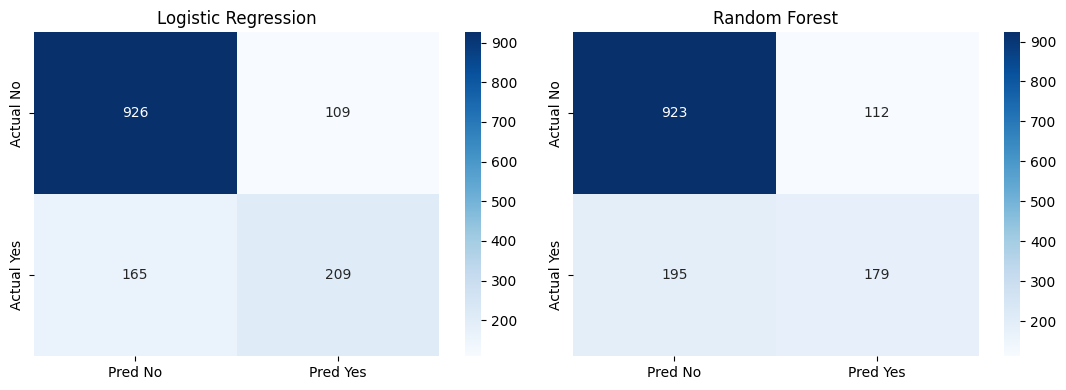

In [22]:
# 9b. Confusion matrix LR vs RF
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, model) in zip(axes, [("Logistic Regression", pipe_lr),
                                    ("Random Forest", pipe_rf)]):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Pred No", "Pred Yes"],
                yticklabels=["Actual No", "Actual Yes"])
    ax.set_title(name)
plt.tight_layout()
plt.show()

# **10. Feature Importance**

**Dua metode digunakan untuk memahami pengaruh global fitur:**

Random Forest feature importance — menangkap pengaruh non-lineardan interaksi antar fitur.

Koefisien Logistic Regression — menunjukkan arah pengaruh(positif/negatif) pada skala yang sudah distandardisasi.

Limitasi: Feature importance mengukur kontribusi prediktif, bukanhubungan sebab-akibat.

Koefisien LR juga sensitif terhadapmultikolinearitas (tenure–TotalCharges = 0,83), sehingga magnitudo antarfitur yang saling berkorelasi diinterpretasi hati-hati.



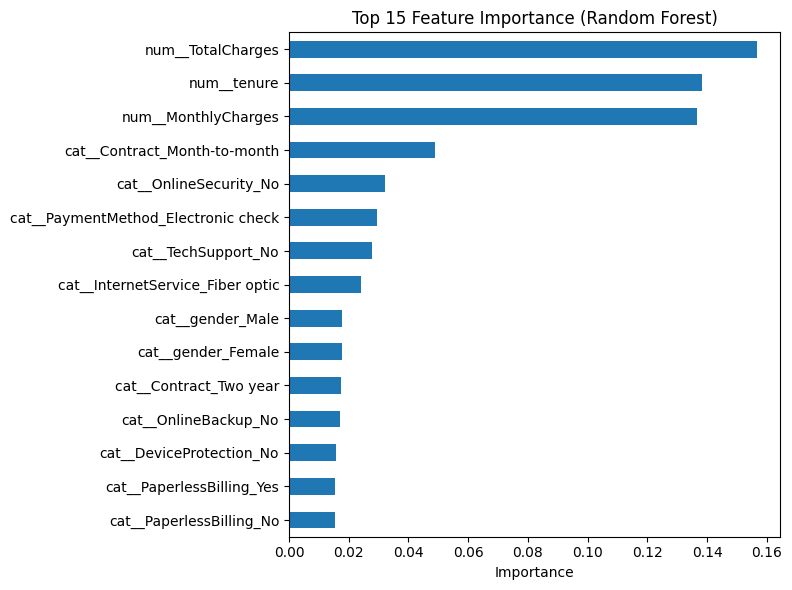

num__TotalCharges                      0.157
num__tenure                            0.138
num__MonthlyCharges                    0.137
cat__Contract_Month-to-month           0.049
cat__OnlineSecurity_No                 0.032
cat__PaymentMethod_Electronic check    0.029
cat__TechSupport_No                    0.028
cat__InternetService_Fiber optic       0.024
cat__gender_Male                       0.018
cat__gender_Female                     0.018
dtype: float64


In [23]:
# =====================================================
# 10. FEATURE IMPORTANCE
# =====================================================
feature_names = pipe_rf.named_steps["prep"].get_feature_names_out()
importances = pipe_rf.named_steps["model"].feature_importances_

feat_imp = (pd.Series(importances, index=feature_names)
              .sort_values(ascending=False))

plt.figure(figsize=(8, 6))
feat_imp.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print(feat_imp.head(10).round(3))

In [24]:
# 10b. Koefisien LR: arah pengaruh terhadap probabilitas churn
coefs = pd.Series(pipe_lr.named_steps["model"].coef_[0],
                  index=pipe_lr.named_steps["prep"].get_feature_names_out())

print("=== 5 pengaruh TERBESAR ke arah CHURN (positif) ===")
print(coefs.sort_values(ascending=False).head(5).round(3))
print("\n=== 5 pengaruh TERBESAR ke arah TETAP BERLANGGANAN (negatif) ===")
print(coefs.sort_values().head(5).round(3))

=== 5 pengaruh TERBESAR ke arah CHURN (positif) ===
cat__InternetService_Fiber optic    0.648
cat__Contract_Month-to-month        0.586
num__TotalCharges                   0.533
cat__StreamingMovies_Yes            0.212
cat__StreamingTV_Yes                0.212
dtype: float64

=== 5 pengaruh TERBESAR ke arah TETAP BERLANGGANAN (negatif) ===
num__tenure                -1.255
cat__Contract_Two year     -0.759
cat__InternetService_DSL   -0.644
num__MonthlyCharges        -0.601
cat__PaperlessBilling_No   -0.331
dtype: float64
